# 3.3 — Opciones exóticas: digitales, barreras, asiáticas y lookback

## Motivación

En 3.1 derivamos Black-Scholes para el payoff europeo más simple, $\max(S_T-K,0)$, y en 3.2 estudiamos sus griegas. Pero la mayoría de los productos que se negocian en mesa no son europeos vainilla: son **path-independent con payoff discontinuo** (digitales), o **dependen de toda la trayectoria** de $S_t$ entre $0$ y $T$ (barreras, asiáticas, lookback). Este notebook cubre cuatro familias que, juntas, tocan casi todas las técnicas de derivación que reaparecerán en módulos posteriores:

- **Digitales (binarias):** el payoff es una indicadora, $\mathbb{1}\{S_T > K\}$ o $S_T\mathbb{1}\{S_T>K\}$. Se derivan directamente de las probabilidades $N(d_2)$ y $N(d_1)$ que ya calculamos en 3.1 — son, literalmente, los dos términos de Black-Scholes por separado.
- **Barreras:** el payoff vainilla se activa o desactiva si $S_t$ toca un nivel $B$ en algún momento $t\in[0,T]$. La derivación usa el **principio de reflexión** del movimiento browniano y un cambio de medida (Girsanov) — la misma maquinaria de 01.5, aplicada a un funcional de la trayectoria completa en vez de solo $S_T$.
- **Asiáticas:** el payoff depende del **promedio** de $S_t$ sobre $[0,T]$. El promedio geométrico hereda lognormalidad de $S_t$ (cierre analítico completo); el promedio aritmético no tiene forma cerrada, lo que motiva Monte Carlo con **variables de control** (adelanto de M4).
- **Lookback flotante:** el payoff usa el **máximo o mínimo** de la trayectoria como strike. Se deriva de la ley conjunta del movimiento browniano con drift y su mínimo corrido — de nuevo reflexión, ahora con drift.

Todas comparten el mismo reto de implementación: cuando el payoff depende de la trayectoria completa, un Monte Carlo con muestreo **discreto** (un número finito $m$ de fechas de monitoreo) no reproduce exactamente el precio de la fórmula cerrada, que asume monitoreo **continuo**. Cuantificamos ese sesgo para la opción barrera y aplicamos la corrección de Broadie-Glasserman-Kou (1997), que reaparecerá cada vez que discreticemos un producto path-dependent.

Parámetros canónicos usados en todo el notebook: $S_0=100$, $K=100$, $r=0.05$, $q=0$, $\sigma=0.20$, $T=1$ año, y barrera $B=90$ (opción down-and-out) cuando aplique.

## 0. Configuración

Reutilizamos `qflib.black.bs_price` para el precio vainilla y `qflib.mc.gbm_paths` para simular trayectorias de $S_t$ bajo $\mathbb{Q}$ (drift $r-q$, esquema exacto log-Euler). El pricing exótico en sí —digitales, barrera, asiáticas, lookback— se deriva y se implementa en este notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from qflib.black import bs_price
from qflib.mc import gbm_paths
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

# Canonical parameters
S0, K, r, q, sigma, T, B = 100.0, 100.0, 0.05, 0.0, 0.20, 1.0, 90.0

print(f"S0={S0}, K={K}, r={r}, q={q}, sigma={sigma}, T={T}, B={B}")
print(f"Vanilla call (qflib.black.bs_price) = {bs_price(S0, K, r, q, sigma, T, 'call'):.6f}")

S0=100.0, K=100.0, r=0.05, q=0.0, sigma=0.2, T=1.0, B=90.0
Vanilla call (qflib.black.bs_price) = 10.450584


## 1. Opciones digitales (binarias)

Una digital paga una cantidad fija o el propio activo si $S_T$ termina de un lado de un strike $K$, sin la "rampa" lineal de una vainilla. Las dos formas estándar (call; el put es análogo con las colas invertidas):

- **Cash-or-nothing:** paga $Q$ (una cantidad fija, tomamos $Q=1$) si $S_T > K$.
- **Asset-or-nothing:** paga $S_T$ si $S_T > K$.

Nótese que un call vainilla es la combinación $\text{AoN} - K\cdot\text{CoN}$: comprar un asset-or-nothing y vender $K$ cash-or-nothing replica exactamente $\max(S_T-K,0)$. Esto nos da una verificación de consistencia gratuita más abajo.

### 1.1 Cash-or-nothing — derivación desde $N(d_2)$

Bajo $\mathbb{Q}$, $\ln S_T \sim \mathcal{N}\!\big(\ln S_0 + (r-q-\tfrac{1}{2}\sigma^2)T,\ \sigma^2 T\big)$ (3.1, Sección 2). El precio es el valor esperado descontado del payoff:
$$
\text{CoN}_{\text{call}} = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\big[Q\cdot\mathbb{1}\{S_T>K\}\big] = Q\,e^{-rT}\,\mathbb{P}^{\mathbb{Q}}(S_T>K).
$$
Escribiendo $S_T = S_0\exp\big((r-q-\tfrac12\sigma^2)T+\sigma\sqrt{T}\,Z\big)$ con $Z\sim\mathcal{N}(0,1)$, el evento $\{S_T>K\}$ equivale a $\{Z > -d_2\}$ con
$$
d_2 = \frac{\ln(S_0/K)+(r-q-\tfrac12\sigma^2)T}{\sigma\sqrt{T}}
$$
(el mismo $d_2$ de Black-Scholes). Por simetría de la normal estándar, $\mathbb{P}(Z>-d_2)=N(d_2)$, así que
$$
\boxed{\text{CoN}_{\text{call}} = Q\,e^{-rT}\,N(d_2)}, \qquad \text{CoN}_{\text{put}} = Q\,e^{-rT}\,N(-d_2).
$$

### 1.2 Asset-or-nothing — derivación desde $N(d_1)$

$$
\text{AoN}_{\text{call}} = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\big[S_T\,\mathbb{1}\{S_T>K\}\big].
$$
Sustituyendo $S_T$ y completando el cuadrado en el exponente ($e^{\sigma\sqrt{T}z}\varphi(z) = e^{\sigma^2T/2}\varphi(z-\sigma\sqrt{T})$, el mismo truco algebraico que aparece en la derivación martingala de 3.1 §2):
$$
\mathbb{E}^{\mathbb{Q}}\big[S_T\,\mathbb{1}\{S_T>K\}\big] = S_0\,e^{(r-q-\frac12\sigma^2)T}\,\mathbb{E}\big[e^{\sigma\sqrt{T}Z}\mathbb{1}\{Z>-d_2\}\big] = S_0\,e^{(r-q)T}\,\mathbb{P}(Z-\sigma\sqrt{T} > -d_2-\sigma\sqrt{T}).
$$
El lado derecho es $S_0e^{(r-q)T}\,\mathbb{P}(Z'>-d_2-\sigma\sqrt{T})$ con $Z'=Z-\sigma\sqrt{T}\sim\mathcal{N}(0,1)$, y $-d_2-\sigma\sqrt{T}=-d_1$, así que la probabilidad es $N(d_1)$. Descontando:
$$
\boxed{\text{AoN}_{\text{call}} = S_0\,e^{-qT}\,N(d_1)}, \qquad \text{AoN}_{\text{put}} = S_0\,e^{-qT}\,N(-d_1).
$$

Nótese la consistencia: $\text{AoN}_{\text{call}} - K\cdot\text{CoN}_{\text{call}} = S_0e^{-qT}N(d_1) - Ke^{-rT}N(d_2)$, exactamente la fórmula de Black-Scholes.

### 1.3 Delta y su explosión cerca de $K$ cuando $T\to 0$

$$
\Delta_{\text{CoN,call}} = \frac{\partial}{\partial S_0}\Big[Q e^{-rT}N(d_2)\Big] = Q\,e^{-rT}\,\varphi(d_2)\,\frac{\partial d_2}{\partial S_0} = \frac{Q\,e^{-rT}\,\varphi(d_2)}{S_0\,\sigma\sqrt{T}}.
$$
A diferencia del delta de una vainilla (acotado en $[0,e^{-qT}]$), este delta tiene un factor $1/\sqrt{T}$ sin compensar: cuando $S_0\to K$ y $T\to 0$ simultáneamente, $d_2\to 0$ pero $\varphi(d_2)/\sqrt{T}\to\infty$. Físicamente: cerca de expiración, una digital ATM es casi una moneda al aire entre pagar $Q$ o $0$ — mover $S_0$ un centavo puede voltear el resultado, así que el hedge dinámico requiere una posición explosivamente grande en el subyacente. Esto es la razón práctica por la que los desks replican digitales con "call spreads" apretados en vez de tratar de delta-hedgear la digital pura cerca de vencimiento.

In [2]:
def _d1_d2(S, K, r, q, sigma, T):
    '''d1, d2 shared by every closed form in este notebook (Section 1).'''
    sqrt_T = np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sqrt_T)
    return d1, d1 - sigma * sqrt_T


def cash_or_nothing_price(S, K, r, q, sigma, T, Q=1.0, kind="call"):
    '''Cash-or-nothing digital price (Section 1.1).'''
    _, d2 = _d1_d2(S, K, r, q, sigma, T)
    if kind == "call":
        return Q * np.exp(-r * T) * norm.cdf(d2)
    elif kind == "put":
        return Q * np.exp(-r * T) * norm.cdf(-d2)
    raise ValueError(f"kind must be 'call' or 'put', got {kind!r}")


def asset_or_nothing_price(S, K, r, q, sigma, T, kind="call"):
    '''Asset-or-nothing digital price (Section 1.2).'''
    d1, _ = _d1_d2(S, K, r, q, sigma, T)
    if kind == "call":
        return S * np.exp(-q * T) * norm.cdf(d1)
    elif kind == "put":
        return S * np.exp(-q * T) * norm.cdf(-d1)
    raise ValueError(f"kind must be 'call' or 'put', got {kind!r}")


def cash_or_nothing_delta(S, K, r, q, sigma, T, Q=1.0, kind="call"):
    '''dPrice/dS of the cash-or-nothing digital (Section 1.3).'''
    _, d2 = _d1_d2(S, K, r, q, sigma, T)
    raw = Q * np.exp(-r * T) * norm.pdf(d2) / (S * sigma * np.sqrt(T))
    return raw if kind == "call" else -raw


# Consistency check: AoN - K*CoN must equal the vanilla call (Section 1, remark)
coN = cash_or_nothing_price(S0, K, r, q, sigma, T, Q=1.0, kind="call")
aoN = asset_or_nothing_price(S0, K, r, q, sigma, T, kind="call")
recon = aoN - K * coN
vanilla = bs_price(S0, K, r, q, sigma, T, "call")
print(f"cash-or-nothing call (Q=1)   = {coN:.6f}")
print(f"asset-or-nothing call        = {aoN:.6f}")
print(f"AoN - K*CoN                  = {recon:.6f}")
print(f"vanilla call (qflib.black)   = {vanilla:.6f}")
np.testing.assert_allclose(recon, vanilla, atol=1e-12)
print("Reconciliacion AoN - K*CoN == vanilla: OK (atol=1e-12).")

cash-or-nothing call (Q=1)   = 0.532325
asset-or-nothing call        = 63.683065
AoN - K*CoN                  = 10.450584
vanilla call (qflib.black)   = 10.450584
Reconciliacion AoN - K*CoN == vanilla: OK (atol=1e-12).


## 2. Demo 1 — precio y delta explosivo de la digital

Graficamos el precio y el delta de la cash-or-nothing call en función de $S_0$, para tres madureces (incluyendo una muy cercana a expiración), fijando $K=100$. Cuando $T\to 0$ el precio converge a un escalón en $K$ y el delta se concentra en un pico cada vez más alto y angosto — la explosión de la Sección 1.3.

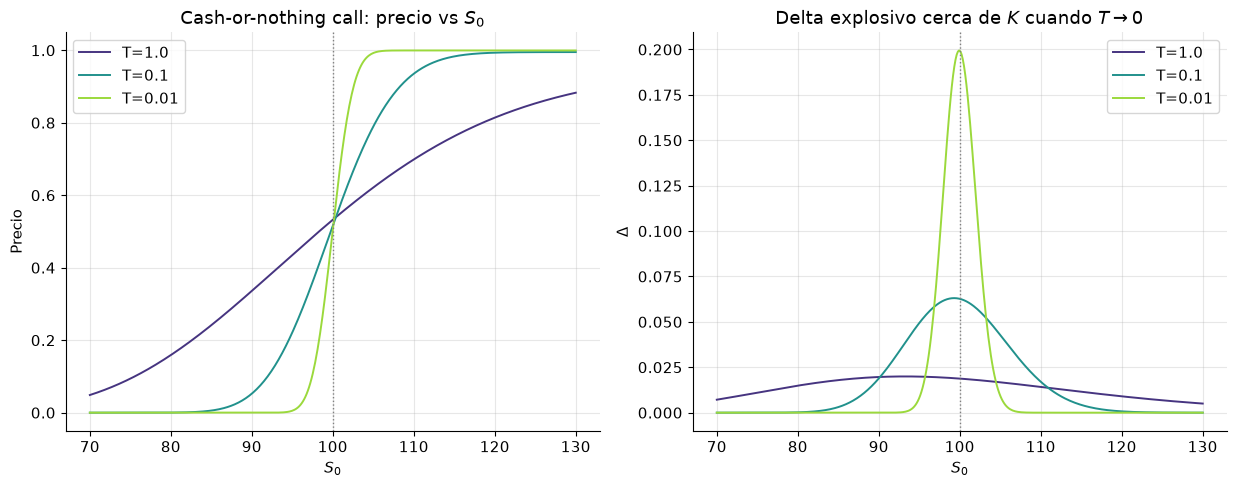

delta ATM (S0=K) a T=  1.0: 0.019
delta ATM (S0=K) a T=  0.1: 0.063
delta ATM (S0=K) a T= 0.01: 0.199


In [3]:
S_grid = np.linspace(70, 130, 400)
T_list = [1.0, 0.10, 0.01]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(T_list)))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
for T_i, c in zip(T_list, colors):
    price = cash_or_nothing_price(S_grid, K, r, q, sigma, T_i, Q=1.0, kind="call")
    delta = cash_or_nothing_delta(S_grid, K, r, q, sigma, T_i, Q=1.0, kind="call")
    axes[0].plot(S_grid, price, color=c, label=f"T={T_i}")
    axes[1].plot(S_grid, delta, color=c, label=f"T={T_i}")

axes[0].axvline(K, color="gray", ls=":", lw=1)
axes[0].set_xlabel("$S_0$"); axes[0].set_ylabel("Precio")
axes[0].set_title("Cash-or-nothing call: precio vs $S_0$")
axes[0].legend()

axes[1].axvline(K, color="gray", ls=":", lw=1)
axes[1].set_xlabel("$S_0$"); axes[1].set_ylabel(r"$\Delta$")
axes[1].set_title(r"Delta explosivo cerca de $K$ cuando $T\to 0$")
axes[1].legend()
plt.tight_layout()
plt.show()

peak_delta = [cash_or_nothing_delta(K, K, r, q, sigma, T_i, Q=1.0, kind="call") for T_i in T_list]
for T_i, pd_ in zip(T_list, peak_delta):
    print(f"delta ATM (S0=K) a T={T_i:>5}: {pd_:.3f}")

## 3. Opciones barrera: reflexión + Girsanov (derivación esquemática)

Una **down-and-out call** (DOC) con barrera $B<S_0$ paga $\max(S_T-K,0)$ solo si la trayectoria **nunca** toca $B$ en $[0,T]$; si la toca, expira sin valor (knock-out). El caso complementario, **down-and-in** (DIC), paga solo si la trayectoria **sí** toca $B$. Como exactamente una de las dos condiciones ocurre en cada trayectoria, se cumple la **paridad in-out**:
$$
\text{DOC} + \text{DIC} = \text{Call vainilla}.
$$
Basta entonces derivar el down-and-in y restar de la vainilla.

### 3.1 Principio de reflexión (caso sin drift)

Sea $W_t$ un browniano estándar y $m_t=\min_{s\leq t}W_s$ su mínimo corrido. El **principio de reflexión** dice que, para $b<0$ y $y\geq b$,
$$
\mathbb{P}(m_T \leq b,\ W_T \in dy) = \mathbb{P}(W_T \in d(2b-y)),
$$
porque cualquier trayectoria que toca $b$ y termina en $y$ tiene una "gemela" reflejada en $b$ a partir del primer toque, que termina en $2b-y$, y ambas son igualmente probables (browniano estándar es simétrico e insensible a reflexiones). Esta identidad da la ley conjunta de $(W_T, m_T)$ en forma cerrada.

### 3.2 De vuelta al drift vía Girsanov

Bajo $\mathbb{Q}$, $\ln(S_t/S_0) = \nu t + \sigma W_t$ con $\nu=r-q-\tfrac12\sigma^2$ — un browniano **con drift**, no el caso sin drift de 3.1. Para reutilizar el principio de reflexión sobre un objeto con drift, se aplica el mismo truco de cambio de medida de 01.5 (Girsanov): se define una medida $\tilde{\mathbb{Q}}$ bajo la cual $\tilde{W}_t = W_t + (\nu/\sigma)t$ es browniano estándar (sin drift), se calcula la probabilidad conjunta de toque-de-barrera y valor terminal usando reflexión bajo $\tilde{\mathbb{Q}}$, y se regresa a $\mathbb{Q}$ multiplicando por la derivada de Radon-Nikodym $d\mathbb{Q}/d\tilde{\mathbb{Q}} = \exp\{-\tfrac{\nu}{\sigma}\tilde W_T - \tfrac12(\nu/\sigma)^2T\}$, evaluada en la trayectoria **reflejada**. Ese factor evaluado en el punto reflejado es precisamente lo que genera el término de potencia $(B/S_0)^{2\mu}$ que aparece en la fórmula final — es la "huella" del cambio de medida. No repetimos aquí el álgebra completa de esa integral (queda fuera del alcance de este notebook); el resultado es un teorema estándar (Reiner-Rubinstein, 1991; también en Björk cap. 15 y Shreve Vol. II cap. 7).

### 3.3 Fórmula cerrada (caso $B\leq K$, que es nuestro caso: $B=90\leq K=100$)

Con $\mu = \dfrac{r-q}{\sigma^2}-\dfrac12$, $\sigma\sqrt{T}$ la desviación estándar total, y
$$
x_1 = \frac{\ln(S_0/K)}{\sigma\sqrt T} + (1+\mu)\sigma\sqrt T, \qquad
y_1 = \frac{\ln\!\big(B^2/(S_0K)\big)}{\sigma\sqrt T} + (1+\mu)\sigma\sqrt T,
$$
el down-and-in call es
$$
\text{DIC} = S_0e^{-qT}\Big(\frac{B}{S_0}\Big)^{2\mu+2} N(y_1) - Ke^{-rT}\Big(\frac{B}{S_0}\Big)^{2\mu} N(y_1-\sigma\sqrt T),
$$
y, por la paridad de la Sección 3, con el vainilla call escrito como $S_0e^{-qT}N(x_1)-Ke^{-rT}N(x_1-\sigma\sqrt T)$ (algebraicamente idéntico a Black-Scholes, solo reparametrizado en $\mu$):
$$
\boxed{\text{DOC} = \Big[S_0e^{-qT}N(x_1)-Ke^{-rT}N(x_1-\sigma\sqrt T)\Big] - \text{DIC}.}
$$

In [4]:
def _mu_barrier(r, q, sigma):
    return (r - q) / sigma**2 - 0.5


def _vanilla_call_rr(S, K, r, q, sigma, T):
    '''Vanilla call in Reiner-Rubinstein's (mu, x1) parametrization (Section 3.3) -- identical to bs_price.'''
    stdDev = sigma * np.sqrt(T)
    muSigma = (1.0 + _mu_barrier(r, q, sigma)) * stdDev
    x1 = np.log(S / K) / stdDev + muSigma
    return S * np.exp(-q * T) * norm.cdf(x1) - K * np.exp(-r * T) * norm.cdf(x1 - stdDev)


def down_and_out_call(S, K, B, r, q, sigma, T):
    '''Down-and-out call, closed form for B <= K (Section 3.3, Reiner-Rubinstein 1991).'''
    if B > K:
        raise NotImplementedError("this notebook only derives the B <= K case")
    stdDev = sigma * np.sqrt(T)
    mu = _mu_barrier(r, q, sigma)
    muSigma = (1.0 + mu) * stdDev
    HS = B / S
    powHS0 = HS ** (2.0 * mu)
    powHS1 = powHS0 * HS**2
    y1 = np.log(B * HS / K) / stdDev + muSigma
    dic = S * np.exp(-q * T) * powHS1 * norm.cdf(y1) - K * np.exp(-r * T) * powHS0 * norm.cdf(y1 - stdDev)
    vanilla = _vanilla_call_rr(S, K, r, q, sigma, T)
    return vanilla - dic


doc_price = down_and_out_call(S0, K, B, r, q, sigma, T)
print(f"vanilla call (RR parametrization) = {_vanilla_call_rr(S0, K, r, q, sigma, T):.6f} "
      f"(vs bs_price = {bs_price(S0, K, r, q, sigma, T, 'call'):.6f})")
print(f"down-and-out call (B={B}, continuous monitoring) = {doc_price:.6f}")

vanilla call (RR parametrization) = 10.450584 (vs bs_price = 10.450584)
down-and-out call (B=90.0, continuous monitoring) = 8.665472


## 4. Sesgo de monitoreo discreto y corrección de Broadie-Glasserman-Kou

La fórmula de la Sección 3 asume que la barrera se vigila **continuamente**: la opción se apaga en cuanto $S_t$ toca $B$ en cualquier instante $t\in[0,T]$. En la práctica (y en cualquier simulación Monte Carlo) solo se observa $S_t$ en $m$ fechas discretas $t_i=i\Delta t$, $\Delta t=T/m$. Una trayectoria puede cruzar $B$ *entre* dos fechas de monitoreo sin que el monitoreo discreto lo detecte, así que la opción discreta se apaga con **menos** frecuencia que la continua:
$$
\text{DOC}_{\text{discreto}}(B,m) \geq \text{DOC}_{\text{continuo}}(B), \qquad \text{con igualdad en el límite } m\to\infty.
$$
Este es exactamente el sesgo que produce un MC ingenuo con monitoreo discreto: sobreestima sistemáticamente el precio del down-and-out frente a la fórmula continua.

**Corrección de Broadie-Glasserman-Kou (1997).** El resultado (vía un principio de reflexión aplicado a un puente browniano entre fechas de monitoreo, y la función zeta de Riemann que aparece al sumar la corrección sobre todos los sub-intervalos) es que, a primer orden en $\Delta t$, el precio discreto se aproxima evaluando la fórmula **continua** en una barrera desplazada:
$$
\text{DOC}_{\text{discreto}}(B,m) \approx \text{DOC}_{\text{continuo}}(B_m), \qquad B_m = B\,e^{-\beta\sigma\sqrt{\Delta t}}, \qquad \beta = \frac{-\zeta(1/2)}{\sqrt{2\pi}} \approx 0.5826,
$$
donde $\zeta$ es la función zeta de Riemann. Para una barrera *down* ($B<S_0$), $B_m<B$: la corrección aleja la barrera un poco más de $S_0$, compensando exactamente el hecho de que el monitoreo discreto "ve menos" cruces que el continuo. (Para una barrera *up* el signo del exponente se invierte, $B_m=Be^{+\beta\sigma\sqrt{\Delta t}}$.)

In [5]:
BETA_BGK = 0.5826  # -zeta(1/2)/sqrt(2*pi), Broadie-Glasserman-Kou (1997)


def bgk_adjusted_barrier(B, sigma, dt, direction="down"):
    '''Continuity-corrected barrier for discrete monitoring (Section 4).'''
    shift = BETA_BGK * sigma * np.sqrt(dt)
    return B * np.exp(-shift) if direction == "down" else B * np.exp(shift)


def mc_discrete_down_and_out_call(S0, K, B, r, q, sigma, T, m, n_paths, rng):
    '''Discretely-monitored down-and-out call by Monte Carlo (Section 4).'''
    paths = gbm_paths(S0, r - q, sigma, T, m, n_paths, rng)
    alive = np.all(paths[:, 1:] > B, axis=1)  # never touches/breaches B at the m monitoring dates
    payoff = np.where(alive, np.maximum(paths[:, -1] - K, 0.0), 0.0)
    disc_payoff = np.exp(-r * T) * payoff
    price = disc_payoff.mean()
    se = disc_payoff.std(ddof=1) / np.sqrt(n_paths)
    return price, se


# sanity check on the adjustment direction: B_m < B for a down barrier
print(f"B = {B}, B_m (m=12) = {bgk_adjusted_barrier(B, sigma, T/12):.4f}, "
      f"B_m (m=252) = {bgk_adjusted_barrier(B, sigma, T/252):.4f}")

B = 90.0, B_m (m=12) = 87.0231, B_m (m=252) = 89.3418


## 5. Demo 2 — barrera: analítico continuo vs MC discreto, sesgo y corrección BGK

Para $m\in\{12, 50, 252\}$ (mensual, semanal aprox., diario) calculamos el precio Monte Carlo del down-and-out discreto y lo comparamos contra (i) la fórmula analítica continua evaluada en $B$ sin corregir, y (ii) la misma fórmula evaluada en la barrera ajustada $B_m$ de BGK. El sesgo frente a (i) debe encogerse con $m$; el precio corregido (ii) debe caer dentro de las bandas de error Monte Carlo para todo $m$.

DOC continuo (analitico, B=90.0)            = 8.665472
    m |  MC discreto |      +-3SE |  sesgo vs continuo |  BGK-corregido |  |MC-BGK|/SE
----------------------------------------------------------------------------------
   12 |     9.587977 |   0.099195 |           0.922505 |       9.580235 |        0.234
   50 |     9.181480 |   0.098702 |           0.516009 |       9.182243 |        0.023
  252 |     8.943446 |   0.098687 |           0.277974 |       8.913921 |        0.898


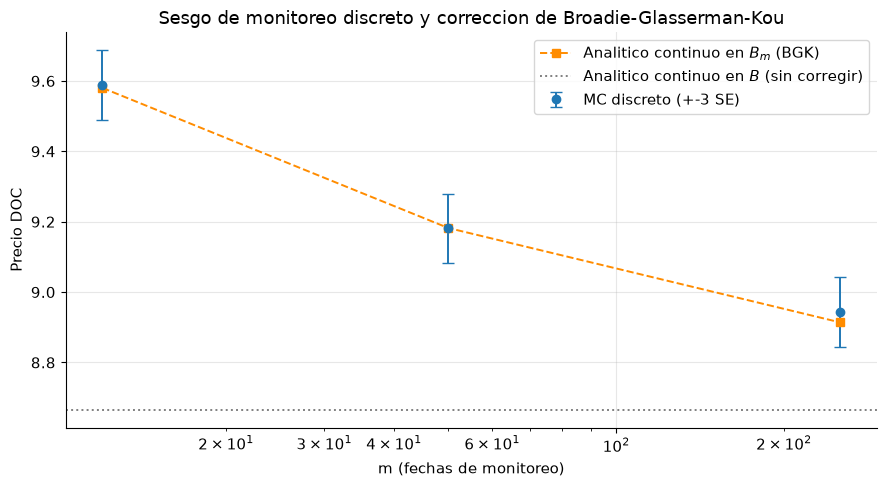

In [6]:
n_paths_barrier = 200_000
m_list = [12, 50, 252]

rows = []
for m in m_list:
    price_mc, se_mc = mc_discrete_down_and_out_call(S0, K, B, r, q, sigma, T, m, n_paths_barrier, rng)
    B_adj = bgk_adjusted_barrier(B, sigma, T / m)
    price_corrected = down_and_out_call(S0, K, B_adj, r, q, sigma, T)
    rows.append((m, price_mc, se_mc, price_corrected))

print(f"DOC continuo (analitico, B={B})            = {doc_price:.6f}")
print(f"{'m':>5} | {'MC discreto':>12} | {'+-3SE':>10} | {'sesgo vs continuo':>18} | {'BGK-corregido':>14} | {'|MC-BGK|/SE':>12}")
print("-" * 82)
for m, price_mc, se_mc, price_corrected in rows:
    bias = price_mc - doc_price
    z = abs(price_mc - price_corrected) / se_mc
    print(f"{m:>5} | {price_mc:>12.6f} | {3*se_mc:>10.6f} | {bias:>18.6f} | {price_corrected:>14.6f} | {z:>12.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
ms = [row[0] for row in rows]
mc_prices = [row[1] for row in rows]
mc_err = [3 * row[2] for row in rows]
corrected = [row[3] for row in rows]
ax.errorbar(ms, mc_prices, yerr=mc_err, fmt="o", capsize=4, label="MC discreto (+-3 SE)")
ax.plot(ms, corrected, "s--", color="darkorange", label="Analitico continuo en $B_m$ (BGK)")
ax.axhline(doc_price, color="gray", ls=":", label="Analitico continuo en $B$ (sin corregir)")
ax.set_xscale("log")
ax.set_xlabel("m (fechas de monitoreo)")
ax.set_ylabel("Precio DOC")
ax.set_title("Sesgo de monitoreo discreto y correccion de Broadie-Glasserman-Kou")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Opciones asiáticas

El payoff depende del promedio de $S_t$ sobre $[0,T]$, no de $S_T$ solo — esto amortigua la volatilidad efectiva del subyacente y hace la opción más barata que la vainilla equivalente.

### 6.1 Promedio geométrico — derivación completa (Kemna-Vorst, 1990)

Definimos el promedio geométrico continuo $G = \exp\!\Big(\frac1T\int_0^T \ln S_t\,dt\Big)$. Bajo $\mathbb{Q}$, $\ln S_t = \ln S_0 + \nu t + \sigma W_t$ con $\nu = r-q-\tfrac12\sigma^2$, así que
$$
\frac1T\int_0^T \ln S_t\,dt = \ln S_0 + \nu\frac{T}{2} + \frac{\sigma}{T}\int_0^T W_t\,dt.
$$
El término $\int_0^T W_t\,dt$ es una integral de un proceso gaussiano, luego gaussiana: media $0$ y varianza $\text{Var}\big(\int_0^TW_t\,dt\big)=\int_0^T\int_0^T\min(s,u)\,ds\,du=\dfrac{T^3}{3}$ (cálculo directo de la covarianza del browniano). Por lo tanto $\ln G$ es **gaussiana**:
$$
\ln G \sim \mathcal{N}\Big(\ln S_0+\nu\tfrac{T}{2},\ \ \sigma_G^2 T\Big), \qquad \sigma_G := \frac{\sigma}{\sqrt3}.
$$
$G$ es entonces **lognormal** — exactamente el mismo tipo de objeto que $S_T$ en Black-Scholes, solo que con volatilidad efectiva $\sigma_G=\sigma/\sqrt3$ y una deriva ajustada. Igualando el primer momento $\mathbb{E}^{\mathbb{Q}}[G]=S_0e^{b_AT+\sigma_G^2T/2}$ con el valor que sale de completar el cuadrado en la lognormal de arriba se obtiene el "costo de acarreo" (cost-of-carry) efectivo
$$
b_A = \frac12\Big(r-q-\frac{\sigma^2}{6}\Big),
$$
y aplicando la fórmula de Black76 sobre el forward $F=S_0e^{b_AT}$ con desviación estándar total $s=\sigma_G\sqrt T=\sigma\sqrt{T/3}$:
$$
\boxed{\text{Asian}_{\text{geom, call}} = e^{-rT}\Big[F\,N(d_1)-K\,N(d_2)\Big]}, \qquad d_1=\frac{\ln(F/K)+\tfrac12 s^2}{s}, \quad d_2=d_1-s.
$$
(Esta es la misma fórmula que implementa `QuantLib::AnalyticContinuousGeometricAveragePriceAsianEngine`, verificado en la Sección de validación.)

### 6.2 Promedio aritmético — sin forma cerrada

El promedio aritmético $A=\frac1T\int_0^TS_t\,dt$ es una suma (integral) de variables lognormales **correlacionadas**, y la suma de lognormales no es lognormal: no hay fórmula cerrada exacta. Lo que sí sabemos, pathwise, es la desigualdad AM-GM: para cualquier trayectoria, el promedio aritmético es $\geq$ el promedio geométrico, así que el payoff aritmético domina punto a punto:
$$
A \geq G \implies \max(A-K,0) \geq \max(G-K,0) \implies \text{Asian}_{\text{arit}} \geq \text{Asian}_{\text{geom}}.
$$
Esta desigualdad, junto con el hecho de que $\text{Asian}_{\text{geom}}$ tiene forma cerrada exacta, es la base de la técnica de **variables de control** que desarrollaremos en M4: usar el error Monte Carlo conocido de $\text{Asian}_{\text{geom}}$ (analítico $-$ MC) para corregir el estimador de $\text{Asian}_{\text{arit}}$, aprovechando que ambos payoffs están altamente correlacionados (misma trayectoria). Aquí solo dejamos vista esa correlación; la implementación completa de la variable de control queda para M4.

### 6.1b Promedio geométrico *discreto* — la misma derivación, con sumas

Cualquier Monte Carlo (y cualquier contrato real) promedia en $m$ fechas $t_i=i\Delta t$, $i=1,\dots,m$, no continuamente. La buena noticia es que la derivación anterior se repite palabra por palabra cambiando la integral por una suma, y sigue siendo **exacta**: $\ln G_m=\frac1m\sum_{i=1}^m \ln S_{t_i}$ es una combinación lineal de gaussianas, luego gaussiana, con
$$
\mathbb{E}[\ln G_m] = \ln S_0 + \nu\,\Delta t\,\frac{m+1}{2},
\qquad
\text{Var}(\ln G_m) = \frac{\sigma^2}{m^2}\sum_{i=1}^m\sum_{j=1}^m \min(t_i,t_j) = \sigma^2\Delta t\,\frac{(m+1)(2m+1)}{6m},
$$
usando $\sum_i\sum_j\min(i,j) = \frac{m(m+1)(2m+1)}{6}$. Con $F_m=e^{\mathbb{E}[\ln G_m]+\frac12\text{Var}(\ln G_m)}$ y $s_m=\sqrt{\text{Var}(\ln G_m)}$ se aplica Black-76 igual que antes. Expandiendo en $1/m$,
$$
\text{Var}(\ln G_m) = \frac{\sigma^2T}{3}\Big(1+\frac{3}{2m}+O(m^{-2})\Big),
$$
así que el promedio discreto tiene **más** varianza que el continuo (promediar en menos puntos suaviza menos) y la asiática discreta es más cara: el sesgo es $O(1/m)$, mucho más benigno que el $O(m^{-1/2})$ del lookback, pero no despreciable frente al error Monte Carlo. Con $m=252$ vale $\approx 0.019$, del orden de $1.6$ errores estándar con $2\times10^5$ trayectorias — razón por la que abajo el MC discreto se valida contra $G_m$, no contra $G$.

In [7]:
def geometric_asian_call_analytic(S0, K, r, q, sigma, T):
    '''Continuous geometric-average Asian call, closed form (Section 6.1, Kemna-Vorst 1990).'''
    b_A = 0.5 * (r - q - sigma**2 / 6.0)
    F = S0 * np.exp(b_A * T)
    s = sigma * np.sqrt(T / 3.0)
    d1 = (np.log(F / K) + 0.5 * s**2) / s
    d2 = d1 - s
    return np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))


def geometric_asian_call_discrete(S0, K, r, q, sigma, T, m):
    '''Discretely-monitored geometric-average Asian call, exact closed form (Section 6.1b).'''
    nu = r - q - 0.5 * sigma**2
    dt = T / m
    mean_log = np.log(S0) + nu * dt * (m + 1) / 2.0
    var_log = sigma**2 * dt * (m + 1) * (2 * m + 1) / (6.0 * m)
    s = np.sqrt(var_log)
    F = np.exp(mean_log + 0.5 * var_log)
    d1 = (np.log(F / K) + 0.5 * s**2) / s
    d2 = d1 - s
    return np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))


def mc_asian_calls(S0, K, r, q, sigma, T, m, n_paths, rng):
    '''MC for geometric AND arithmetic discretely-monitored Asian calls, same paths (Section 6.2).'''
    paths = gbm_paths(S0, r - q, sigma, T, m, n_paths, rng)
    obs = paths[:, 1:]  # m monitoring dates t_i = i*T/m, i=1..m
    A = obs.mean(axis=1)
    G = np.exp(np.log(obs).mean(axis=1))
    disc = np.exp(-r * T)
    payoff_A = disc * np.maximum(A - K, 0.0)
    payoff_G = disc * np.maximum(G - K, 0.0)
    result = {
        "price_A": payoff_A.mean(), "se_A": payoff_A.std(ddof=1) / np.sqrt(n_paths),
        "price_G": payoff_G.mean(), "se_G": payoff_G.std(ddof=1) / np.sqrt(n_paths),
        "corr_AG": np.corrcoef(payoff_A, payoff_G)[0, 1],
    }
    return result


geo_analytic = geometric_asian_call_analytic(S0, K, r, q, sigma, T)
print(f"Asian geometrica (analitico) = {geo_analytic:.6f}")
geo_analytic_disc = geometric_asian_call_discrete(S0, K, r, q, sigma, T, 252)
print(f"Asian geometrica discreta (analitico, m=252) = {geo_analytic_disc:.6f}")

Asian geometrica (analitico) = 5.546819
Asian geometrica discreta (analitico, m=252) = 5.565509


## 7. Demo 3 — asiática geométrica analítica vs MC; aritmética por MC (preview control variates)

Con $m=252$ fechas de monitoreo (diario) comparamos la geométrica MC contra la fórmula cerrada **discreta** de la Sección 6.1b — la que corresponde a lo que el MC realmente simula — y, aparte, tabulamos la convergencia $G_m\to G$ para exhibir el orden $O(1/m)$ del sesgo de promediado (esto es puro cálculo analítico, sin Monte Carlo). Luego calculamos la aritmética por MC sobre las **mismas trayectorias** y verificamos $\text{Asian}_{\text{arit}} \geq \text{Asian}_{\text{geom}}$ junto con la correlación entre ambos payoffs (el ingrediente clave de la variable de control de M4: mientras más cercana a 1, mayor la reducción de varianza que se obtendrá al usar la geométrica como control).

Geometrica continua (analitico)        : 5.546819
Geometrica discreta m=252 (analitico)  : 5.565509
Geometrica MC (m=252)                  : 5.598521 +- 0.052031 (3 SE)
  |MC - discreta| / SE = 1.903 (dentro de 3 si <= 3)
  |MC - continua| / SE = 2.981 <- sesgo de promediado, no ruido MC

Convergencia analitica G_m -> G (sin Monte Carlo):
     m |   discreta |     sesgo |  sesgo*m
------------------------------------------
    12 |   5.940200 |  0.393382 |   4.7206
    50 |   5.641058 |  0.094239 |   4.7120
   252 |   5.565509 |  0.018690 |   4.7099
  1008 |   5.551491 |  0.004672 |   4.7096
Aritmetica  -- MC: 5.816095 +- 0.053892 (3 SE)  [sin forma cerrada]
Asian_arit - Asian_geom (MC) = 0.217574  (debe ser >= 0 por AM >= GM, Seccion 6.2)
Correlacion (payoff_arit, payoff_geom) = 0.9996  (preview control variates, M4)


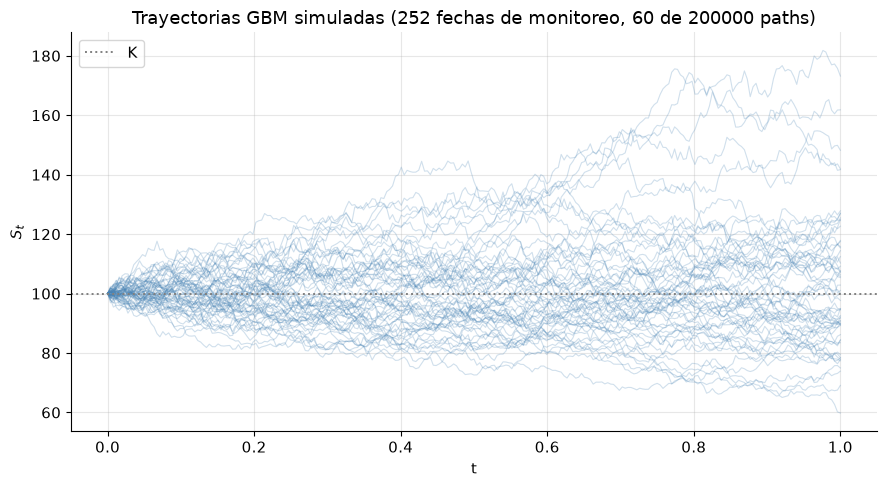

In [8]:
n_paths_asian = 200_000
m_asian = 252

res = mc_asian_calls(S0, K, r, q, sigma, T, m_asian, n_paths_asian, rng)
geo_disc_asian = geometric_asian_call_discrete(S0, K, r, q, sigma, T, m_asian)

print(f"Geometrica continua (analitico)        : {geo_analytic:.6f}")
print(f"Geometrica discreta m={m_asian} (analitico)  : {geo_disc_asian:.6f}")
print(f"Geometrica MC (m={m_asian})                  : {res['price_G']:.6f} +- {3*res['se_G']:.6f} (3 SE)")
z_geo = abs(res['price_G'] - geo_disc_asian) / res['se_G']
z_geo_cont = abs(res['price_G'] - geo_analytic) / res['se_G']
print(f"  |MC - discreta| / SE = {z_geo:.3f} (dentro de 3 si <= 3)")
print(f"  |MC - continua| / SE = {z_geo_cont:.3f} <- sesgo de promediado, no ruido MC")

print(f"\nConvergencia analitica G_m -> G (sin Monte Carlo):")
print(f"{'m':>6} | {'discreta':>10} | {'sesgo':>9} | {'sesgo*m':>8}")
print("-" * 42)
m_grid_asian = [12, 50, 252, 1008]
bias_times_m = []
for m in m_grid_asian:
    d = geometric_asian_call_discrete(S0, K, r, q, sigma, T, m)
    bias_times_m.append((d - geo_analytic) * m)
    print(f"{m:>6} | {d:>10.6f} | {d - geo_analytic:>9.6f} | {bias_times_m[-1]:>8.4f}")

print(f"Aritmetica  -- MC: {res['price_A']:.6f} +- {3*res['se_A']:.6f} (3 SE)  [sin forma cerrada]")
print(f"Asian_arit - Asian_geom (MC) = {res['price_A'] - res['price_G']:.6f}  (debe ser >= 0 por AM >= GM, Seccion 6.2)")
print(f"Correlacion (payoff_arit, payoff_geom) = {res['corr_AG']:.4f}  (preview control variates, M4)")

assert res["price_A"] >= res["price_G"], "arithmetic Asian call must dominate geometric pathwise (AM >= GM)"

fig, ax = plt.subplots(figsize=(9, 5))
paths_plot = gbm_paths(S0, r - q, sigma, T, m_asian, 60, np.random.default_rng(7))
t_grid = np.linspace(0, T, m_asian + 1)
ax.plot(t_grid, paths_plot.T, color="steelblue", alpha=0.25, lw=0.8)
ax.axhline(K, color="gray", ls=":", label="K")
ax.set_xlabel("t"); ax.set_ylabel("$S_t$")
ax.set_title(f"Trayectorias GBM simuladas ({m_asian} fechas de monitoreo, 60 de {n_paths_asian} paths)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Opción lookback flotante — derivación esquemática vía el máximo del BM con drift

Una lookback call de **strike flotante** paga $S_T - m_T$, con $m_T=\min_{0\leq t\leq T}S_t$ el mínimo corrido de la trayectoria (asumimos que la opción "nace" hoy, así que $m_0=S_0$ — el mínimo corrido al inicio es el spot actual). Es, en cierto sentido, la opción "perfecta": el comprador siempre pudo haber comprado al mínimo histórico.

### 8.1 El objeto relevante: la ley conjunta de $(X_T, \min_{t\leq T}X_t)$

Escribimos $S_t = S_0e^{X_t}$ con $X_t=\nu t+\sigma W_t$ (el mismo browniano con drift $\nu=r-q-\tfrac12\sigma^2$ de la Sección 3.2). Entonces $m_T=S_0\exp\big(\min_{t\leq T}X_t\big)$, y el precio requiere la ley conjunta de $(X_T,\min_{t\leq T}X_t)$. Esta es la misma construcción que usamos para barreras (Sección 3): se aplica el principio de reflexión a la parte sin drift y se usa Girsanov para reintroducir $\nu$, generando de nuevo un término de potencia (aquí con exponente $\lambda=2(r-q)/\sigma^2$ en vez de $2\mu$). La derivación explícita de esa integral conjunta es un resultado clásico (Harrison, 1985, cap. 1; también Karatzas-Shreve) que no repetimos aquí en detalle — el resultado final fue obtenido primero por Goldman, Sosin y Gatto (1979) y refinado con dividendos por Conze y Viswanathan (1991).

### 8.2 Fórmula cerrada

Con $\lambda = \dfrac{2(r-q)}{\sigma^2}$, $s=S_0/m_0$, y
$$
d_1 = \frac{\ln s}{\sigma\sqrt T} + \frac12(\lambda+1)\sigma\sqrt T, \qquad d_2=d_1-\sigma\sqrt T,
$$
el precio de la lookback call de strike flotante (con dividendo continuo $q$) es
$$
\boxed{
\text{Lookback}_{\text{call}} = S_0e^{-qT}N(d_1) - m_0e^{-rT}N(d_2) + \frac{S_0}{\lambda}\Big[e^{-rT}s^{-\lambda}N(-d_1+\lambda\sigma\sqrt T) - e^{-qT}N(-d_1)\Big].
}
$$
El primer término se parece al asset-or-nothing de la Sección 1 (la parte "$S_T$ grande"), el segundo es el mínimo corrido descontado, y el tercero es la corrección que viene del principio de reflexión — el mismo tipo de término de potencia que apareció en la barrera. Esta parametrización coincide con la transcrita en Haug (*Complete Guide to Option Pricing Formulas*) y es la que implementa `QuantLib::AnalyticContinuousFloatingLookbackEngine`.

In [9]:
def floating_lookback_call_analytic(S0, m0, r, q, sigma, T):
    '''Floating-strike lookback call, closed form (Section 8.2, Goldman-Sosin-Gatto 1979 / Conze-Viswanathan 1991).'''
    stdDev = sigma * np.sqrt(T)
    lam = 2.0 * (r - q) / sigma**2
    s = S0 / m0
    d1 = np.log(s) / stdDev + 0.5 * (lam + 1.0) * stdDev
    d2 = d1 - stdDev
    n1, n2 = norm.cdf(d1), norm.cdf(d2)
    n3, n4 = norm.cdf(-d1 + lam * stdDev), norm.cdf(-d1)
    pow_s = s ** (-lam)
    return (S0 * np.exp(-q * T) * n1 - m0 * np.exp(-r * T) * n2
            + (S0 / lam) * (np.exp(-r * T) * pow_s * n3 - np.exp(-q * T) * n4))


lookback_analytic = floating_lookback_call_analytic(S0, S0, r, q, sigma, T)
print(f"Lookback flotante call (analitico, m0=S0={S0}) = {lookback_analytic:.6f}")

Lookback flotante call (analitico, m0=S0=100.0) = 17.216802


## 9. Demo 4 — lookback flotante: el sesgo de monitoreo es de *primer* orden

Aquí el monitoreo discreto muerde mucho más fuerte que en la barrera, y conviene decirlo con precisión: el mínimo observado en $m$ fechas siempre está **por encima** del mínimo continuo, así que el payoff $S_T - m_T$ se subestima y el precio Monte Carlo queda sistemáticamente **por debajo** de la fórmula continua. La magnitud no es de segundo orden: es $O(\sqrt{\Delta t}) = O(m^{-1/2})$, el mismo orden que el error de un puente browniano, porque el mínimo continuo se alcanza típicamente *dentro* de un intervalo de monitoreo y no en sus extremos. Con $m=252$ el sesgo es de casi $0.6$ en un precio de $17.2$ (≈3.3 %), decenas de errores estándar con $2\times10^5$ trayectorias: ningún $m$ razonable lo hace desaparecer.

**La misma corrección BGK, aplicada al extremo corrido.** El resultado de Broadie-Glasserman-Kou (1997, 1999) sobre la distribución del mínimo discreto es el mismo desplazamiento de la Sección 4, ahora leído como reescalamiento del extremo:
$$
\mathbb{P}\big(m_T^{(m)} < b\big) \approx \mathbb{P}\big(m_T^{\text{cont}} < b\,e^{-\beta\sigma\sqrt{\Delta t}}\big)
\quad\Longleftrightarrow\quad
m_T^{(m)} \;\overset{d}{\approx}\; e^{\beta\sigma\sqrt{\Delta t}}\, m_T^{\text{cont}}.
$$
Para pasar esto a precio basta una identidad: el payoff se separa en $S_T$ menos el mínimo, y $\mathbb{E}^{\mathbb{Q}}[e^{-rT}S_T] = S_0e^{-qT}$, así que
$$
V_{\text{cont}} = S_0e^{-qT} - \mathbb{E}^{\mathbb{Q}}\big[e^{-rT}m_T^{\text{cont}}\big]
\quad\Longrightarrow\quad
\mathbb{E}^{\mathbb{Q}}\big[e^{-rT}m_T^{\text{cont}}\big] = S_0e^{-qT} - V_{\text{cont}}.
$$
Sustituyendo el reescalamiento del mínimo en esa descomposición:
$$
\boxed{\;V^{(m)} \approx S_0e^{-qT} - e^{\beta\sigma\sqrt{\Delta t}}\big(S_0e^{-qT} - V_{\text{cont}}\big)\;}
$$
y a primer orden el sesgo queda explícito:
$$
V^{(m)} - V_{\text{cont}} \approx -\beta\sigma\sqrt{\Delta t}\,\big(S_0e^{-qT} - V_{\text{cont}}\big) = -\frac{\beta\sigma\,(S_0e^{-qT} - V_{\text{cont}})\sqrt{T}}{\sqrt{m}},
$$
es decir $\text{sesgo}\times\sqrt{m}$ debe ser aproximadamente **constante** — la firma numérica que verificamos abajo.

Para medir el sesgo limpiamente simulamos **una sola** malla fina ($m_{\max}=2016$) y submuestreamos las mallas gruesas de ella: todas las frecuencias comparten trayectorias y el mismo $S_T$, así que las diferencias entre ellas son casi puro sesgo y no ruido Monte Carlo.

Lookback flotante continuo (analitico) = 17.216802
     m |  MC discreto |     +-3SE |     sesgo | sesgo*sqrt(m) | BGK-corregido | |MC-BGK|/SE
----------------------------------------------------------------------------------------------
    63 |    16.052064 |  0.097409 | -1.164738 |       -9.2448 |     15.992569 |       1.832
   126 |    16.384121 |  0.097515 | -0.832681 |       -9.3468 |     16.353002 |       0.957
   252 |    16.625364 |  0.097591 | -0.591438 |       -9.3888 |     16.606932 |       0.567
   504 |    16.796850 |  0.097635 | -0.419952 |       -9.4279 |     16.786023 |       0.333
  1008 |    16.919717 |  0.097668 | -0.297085 |       -9.4322 |     16.912427 |       0.224
  2016 |    17.007498 |  0.097696 | -0.209305 |       -9.3978 |     17.001692 |       0.178

sesgo*sqrt(m) predicho a primer orden = -9.6459


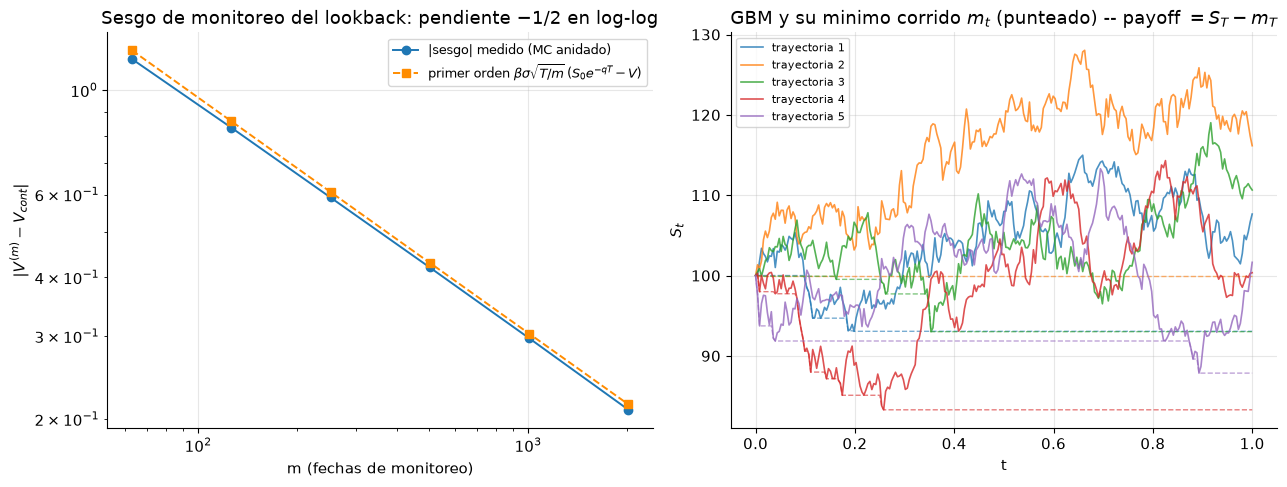

In [10]:
def bgk_lookback_price(V_cont, S0, q, sigma, T, m):
    '''Discrete-monitoring floating lookback call from the continuous price (Section 9).'''
    forward_pv = S0 * np.exp(-q * T)
    return forward_pv - np.exp(BETA_BGK * sigma * np.sqrt(T / m)) * (forward_pv - V_cont)


def mc_lookback_nested(S0, r, q, sigma, T, ms, n_paths, rng, chunk=10_000):
    '''Floating-strike lookback call by MC at several monitoring frequencies at once (Section 9).

    Simulates the finest grid max(ms) once and subsamples the coarser ones from it, so every
    frequency shares paths and terminal value. Requires each m to divide max(ms).
    '''
    m_max = max(ms)
    assert all(m_max % m == 0 for m in ms), "each m must divide max(ms)"
    acc = {m: [0.0, 0.0] for m in ms}  # sum, sum of squares
    n_done = 0
    while n_done < n_paths:
        n_chunk = min(chunk, n_paths - n_done)
        paths = gbm_paths(S0, r - q, sigma, T, m_max, n_chunk, rng)  # includes t=0, so m0=S0
        ST = paths[:, -1]
        for m in ms:
            sub = paths[:, :: m_max // m]  # keeps t=0 and t=T
            disc_payoff = np.exp(-r * T) * (ST - sub.min(axis=1))
            acc[m][0] += disc_payoff.sum()
            acc[m][1] += (disc_payoff**2).sum()
        n_done += n_chunk
    out = {}
    for m, (s1, s2) in acc.items():
        mean = s1 / n_done
        var = (s2 - n_done * mean**2) / (n_done - 1)
        out[m] = (mean, np.sqrt(var / n_done))
    return out


n_paths_lookback = 200_000
m_list_lookback = [63, 126, 252, 504, 1008, 2016]
m_lookback = 252  # frecuencia de referencia (diaria) para la validacion de la Seccion 10

lb_mc_by_m = mc_lookback_nested(S0, r, q, sigma, T, m_list_lookback, n_paths_lookback,
                                np.random.default_rng(202))
lb_mc, lb_se = lb_mc_by_m[m_lookback]

print(f"Lookback flotante continuo (analitico) = {lookback_analytic:.6f}")
print(f"{'m':>6} | {'MC discreto':>12} | {'+-3SE':>9} | {'sesgo':>9} | {'sesgo*sqrt(m)':>13} | "
      f"{'BGK-corregido':>13} | {'|MC-BGK|/SE':>11}")
print("-" * 94)
for m in m_list_lookback:
    price_mc, se_mc = lb_mc_by_m[m]
    bias = price_mc - lookback_analytic
    price_bgk = bgk_lookback_price(lookback_analytic, S0, q, sigma, T, m)
    print(f"{m:>6} | {price_mc:>12.6f} | {3*se_mc:>9.6f} | {bias:>9.6f} | {bias*np.sqrt(m):>13.4f} | "
          f"{price_bgk:>13.6f} | {abs(price_mc - price_bgk)/se_mc:>11.3f}")

bias_first_order = -BETA_BGK * sigma * (S0 * np.exp(-q * T) - lookback_analytic) * np.sqrt(T)
print(f"\nsesgo*sqrt(m) predicho a primer orden = {bias_first_order:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ms_arr = np.array(m_list_lookback, dtype=float)
biases = np.array([lb_mc_by_m[m][0] - lookback_analytic for m in m_list_lookback])
ax.plot(ms_arr, -biases, "o-", label="$|$sesgo$|$ medido (MC anidado)")
ax.plot(ms_arr, -bias_first_order / np.sqrt(ms_arr), "s--", color="darkorange",
        label=r"primer orden $\beta\sigma\sqrt{T/m}\,(S_0e^{-qT}-V)$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("m (fechas de monitoreo)"); ax.set_ylabel("$|V^{(m)} - V_{cont}|$")
ax.set_title(r"Sesgo de monitoreo del lookback: pendiente $-1/2$ en log-log")
ax.legend(fontsize=9)

ax = axes[1]
paths_plot = gbm_paths(S0, r - q, sigma, T, m_lookback, 5, np.random.default_rng(11))
t_grid = np.linspace(0, T, m_lookback + 1)
for i, path in enumerate(paths_plot):
    line, = ax.plot(t_grid, path, alpha=0.8, lw=1.2, label=f"trayectoria {i+1}")
    ax.plot(t_grid, np.minimum.accumulate(path), ls="--", color=line.get_color(), alpha=0.6, lw=1.0)
ax.set_xlabel("t"); ax.set_ylabel("$S_t$")
ax.set_title(r"GBM y su minimo corrido $m_t$ (punteado) -- payoff $= S_T - m_T$")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Validación contra QuantLib

Comparamos las cuatro familias contra los engines analíticos de QuantLib con `AnalyticEuropeanEngine` + `CashOrNothingPayoff`/`AssetOrNothingPayoff` (digitales), `AnalyticBarrierEngine` (barrera), `AnalyticContinuousGeometricAveragePriceAsianEngine` (asiática geométrica) y `AnalyticContinuousFloatingLookbackEngine` (lookback) — mismo setup que 3.1: `eval_date=ql.Date(29,7,2026)`, `Actual365Fixed`, curvas planas. Tolerancia analítico-vs-analítico: `atol=1e-8`. Para el Monte Carlo discreto de la barrera comparamos contra el analítico continuo evaluado en la barrera corregida por BGK (Sección 4-5), dentro de 3 SE.

In [11]:
import QuantLib as ql

eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()
calendar = ql.NullCalendar()

maturity = eval_date + int(round(T * 365))
T_actual = day_count.yearFraction(eval_date, maturity)
exercise = ql.EuropeanExercise(maturity)

spot_handle = ql.QuoteHandle(ql.SimpleQuote(S0))
rate_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, r, day_count))
div_ts = ql.YieldTermStructureHandle(ql.FlatForward(eval_date, q, day_count))
vol_ts = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(eval_date, calendar, sigma, day_count))
process = ql.BlackScholesMertonProcess(spot_handle, div_ts, rate_ts, vol_ts)

print(f"T_actual = {T_actual} (target T = {T})")

T_actual = 1.0 (target T = 1.0)


In [12]:
# --- Digitales ---
euro_engine = ql.AnalyticEuropeanEngine(process)

cash_payoff = ql.CashOrNothingPayoff(ql.Option.Call, K, 1.0)
cash_opt = ql.VanillaOption(cash_payoff, exercise)
cash_opt.setPricingEngine(euro_engine)
ql_coN = cash_opt.NPV()
py_coN = cash_or_nothing_price(S0, K, r, q, sigma, T_actual, Q=1.0, kind="call")

asset_payoff = ql.AssetOrNothingPayoff(ql.Option.Call, K)
asset_opt = ql.VanillaOption(asset_payoff, exercise)
asset_opt.setPricingEngine(euro_engine)
ql_aoN = asset_opt.NPV()
py_aoN = asset_or_nothing_price(S0, K, r, q, sigma, T_actual, kind="call")

print(f"{'':14} | {'QuantLib':>14} | {'python':>14} | {'diff':>10}")
print("-" * 60)
print(f"{'cash-or-none':14} | {ql_coN:>14.10f} | {py_coN:>14.10f} | {abs(ql_coN-py_coN):>10.2e}")
print(f"{'asset-or-none':14} | {ql_aoN:>14.10f} | {py_aoN:>14.10f} | {abs(ql_aoN-py_aoN):>10.2e}")

np.testing.assert_allclose(py_coN, ql_coN, atol=1e-8)
np.testing.assert_allclose(py_aoN, ql_aoN, atol=1e-8)
print("Digitales: dentro de atol=1e-8.")

               |       QuantLib |         python |       diff
------------------------------------------------------------
cash-or-none   |   0.5323248155 |   0.5323248155 |   0.00e+00
asset-or-none  |  63.6830651176 |  63.6830651176 |   1.42e-14
Digitales: dentro de atol=1e-8.


In [13]:
# --- Barrera (analitico continuo, atol 1e-8; MC discreto vs BGK, 3 SE) ---
barrier_opt = ql.BarrierOption(ql.Barrier.DownOut, B, 0.0, ql.PlainVanillaPayoff(ql.Option.Call, K), exercise)
barrier_opt.setPricingEngine(ql.AnalyticBarrierEngine(process))
ql_doc = barrier_opt.NPV()
py_doc = down_and_out_call(S0, K, B, r, q, sigma, T_actual)
print(f"DOC continuo -- QuantLib: {ql_doc:.10f} | python: {py_doc:.10f} | diff: {abs(ql_doc-py_doc):.2e}")
np.testing.assert_allclose(py_doc, ql_doc, atol=1e-8)
print("Barrera analitica continua: dentro de atol=1e-8.")

print()
print(f"{'m':>5} | {'MC discreto':>12} | {'BGK-corregido (analitico)':>26} | {'|diff|/SE':>10} | {'<=3?':>5}")
for m, price_mc, se_mc, price_corrected in rows:
    z = abs(price_mc - price_corrected) / se_mc
    print(f"{m:>5} | {price_mc:>12.6f} | {price_corrected:>26.6f} | {z:>10.3f} | {str(z <= 3):>5}")
    assert z <= 3.0, f"MC discreto (m={m}) fuera de 3 SE del analitico BGK-corregido"
print("Barrera discreta (MC) vs analitico BGK-corregido: dentro de 3 SE para todo m.")

DOC continuo -- QuantLib: 8.6654716582 | python: 8.6654716582 | diff: 1.24e-14
Barrera analitica continua: dentro de atol=1e-8.

    m |  MC discreto |  BGK-corregido (analitico) |  |diff|/SE |  <=3?
   12 |     9.587977 |                   9.580235 |      0.234 |  True
   50 |     9.181480 |                   9.182243 |      0.023 |  True
  252 |     8.943446 |                   8.913921 |      0.898 |  True
Barrera discreta (MC) vs analitico BGK-corregido: dentro de 3 SE para todo m.


In [14]:
# --- Asiatica geometrica ---
asian_payoff = ql.PlainVanillaPayoff(ql.Option.Call, K)
asian_opt = ql.ContinuousAveragingAsianOption(ql.Average().Geometric, asian_payoff, exercise)
asian_opt.setPricingEngine(ql.AnalyticContinuousGeometricAveragePriceAsianEngine(process))
ql_geo = asian_opt.NPV()
py_geo = geometric_asian_call_analytic(S0, K, r, q, sigma, T_actual)
print(f"Asian geometrica -- QuantLib: {ql_geo:.10f} | python: {py_geo:.10f} | diff: {abs(ql_geo-py_geo):.2e}")
np.testing.assert_allclose(py_geo, ql_geo, atol=1e-8)
print("Asiatica geometrica analitica: dentro de atol=1e-8.")

# El MC de la Seccion 7 promedia en m fechas: se compara contra la forma cerrada discreta
# (Seccion 6.1b), no contra la continua -- el sesgo de promediado es O(1/m), ~1.6 SE en m=252.
ql_geo_disc = geometric_asian_call_discrete(S0, K, r, q, sigma, T_actual, m_asian)
z_geo_mc = abs(res["price_G"] - ql_geo_disc) / res["se_G"]
print(f"Asian geometrica MC (m={m_asian}) vs analitico discreto ({ql_geo_disc:.6f}): "
      f"|diff|/SE = {z_geo_mc:.3f} (<=3? {z_geo_mc <= 3.0})")
assert z_geo_mc <= 3.0

# Firma del sesgo de promediado: sesgo*m constante => orden 1/m (rtol 5% entre los extremos de m)
spread_asian = max(bias_times_m) / min(bias_times_m)
print(f"sesgo*m en m={m_grid_asian[0]}..{m_grid_asian[-1]}: "
      f"{bias_times_m[0]:.4f} .. {bias_times_m[-1]:.4f} (razon {spread_asian:.4f})")
assert abs(spread_asian - 1.0) <= 0.05

Asian geometrica -- QuantLib: 5.5468186338 | python: 5.5468186338 | diff: 8.88e-16
Asiatica geometrica analitica: dentro de atol=1e-8.
Asian geometrica MC (m=252) vs analitico discreto (5.565509): |diff|/SE = 1.903 (<=3? True)
sesgo*m en m=12..1008: 4.7206 .. 4.7096 (razon 1.0023)


In [15]:
# --- Lookback flotante ---
lookback_payoff = ql.FloatingTypePayoff(ql.Option.Call)
lookback_opt = ql.ContinuousFloatingLookbackOption(S0, lookback_payoff, exercise)
lookback_opt.setPricingEngine(ql.AnalyticContinuousFloatingLookbackEngine(process))
ql_lookback = lookback_opt.NPV()
py_lookback = floating_lookback_call_analytic(S0, S0, r, q, sigma, T_actual)
print(f"Lookback -- QuantLib: {ql_lookback:.10f} | python: {py_lookback:.10f} | diff: {abs(ql_lookback-py_lookback):.2e}")
np.testing.assert_allclose(py_lookback, ql_lookback, atol=1e-8)
print("Lookback flotante analitico: dentro de atol=1e-8.")

# El MC de la Seccion 9 monitorea en m fechas: se compara contra el valor BGK-corregido,
# no contra el continuo (el sesgo de monitoreo es O(m^-1/2), decenas de SE -- ver Seccion 9).
lb_bgk = bgk_lookback_price(ql_lookback, S0, q, sigma, T_actual, m_lookback)
z_lb_ql = abs(lb_mc - lb_bgk) / lb_se
print(f"Lookback MC (m={m_lookback}) vs QuantLib+BGK ({lb_bgk:.6f}): |diff|/SE = {z_lb_ql:.3f} (<=3? {z_lb_ql <= 3.0})")
assert z_lb_ql <= 3.0

# Firma del sesgo: sesgo*sqrt(m) constante => orden m^-1/2 (rtol 15% entre los extremos de m)
scaled_bias = np.array([(lb_mc_by_m[m][0] - lookback_analytic) * np.sqrt(m) for m in m_list_lookback])
spread = scaled_bias.max() / scaled_bias.min()  # ambos negativos
print(f"sesgo*sqrt(m) en m={m_list_lookback[0]}..{m_list_lookback[-1]}: "
      f"{scaled_bias[0]:.4f} .. {scaled_bias[-1]:.4f} (razon {spread:.4f})")
assert abs(spread - 1.0) <= 0.15

print()
print("Validacion completa: 4/4 familias dentro de tolerancia.")

Lookback -- QuantLib: 17.2168022374 | python: 17.2168022374 | diff: 1.07e-14
Lookback flotante analitico: dentro de atol=1e-8.
Lookback MC (m=252) vs QuantLib+BGK (16.606932): |diff|/SE = 0.567 (<=3? True)
sesgo*sqrt(m) en m=63..2016: -9.2448 .. -9.3978 (razon 0.9801)

Validacion completa: 4/4 familias dentro de tolerancia.


## Referencias

- Reiner, E. & Rubinstein, M. (1991). *Breaking Down the Barriers*. Risk Magazine, 4(8), 28-35.
- Kemna, A.G.Z. & Vorst, A.C.F. (1990). *A Pricing Method for Options Based on Average Asset Values*. Journal of Banking and Finance, 14(1), 113-129.
- Broadie, M., Glasserman, P. & Kou, S.G. (1997). *A Continuity Correction for Discrete Barrier Options*. Mathematical Finance, 7(4), 325-349.
- Broadie, M., Glasserman, P. & Kou, S.G. (1999). *Connecting Discrete and Continuous Path-Dependent Options*. Finance and Stochastics, 3(1), 55-82. (extensión de la corrección de continuidad a lookbacks y extremos corridos)
- Goldman, M.B., Sosin, H.B. & Gatto, M.A. (1979). *Path Dependent Options: Buy at the Low, Sell at the High*. Journal of Finance, 34(5), 1111-1127.
- Conze, A. & Viswanathan, R. (1991). *Path Dependent Options: The Case of Lookback Options*. Journal of Finance, 46(5), 1893-1907.
- Hull, J.C. *Options, Futures, and Other Derivatives*, 10th ed., cap. 26 (opciones exóticas).
- Haug, E.G. (2007). *The Complete Guide to Option Pricing Formulas*, 2nd ed., McGraw-Hill, cap. 4 (barreras, asiáticas, lookback).
- Harrison, J.M. (1985). *Brownian Motion and Stochastic Flow Systems*, Wiley, cap. 1 (ley conjunta de BM con drift y su mínimo/máximo corrido).